<a href="https://colab.research.google.com/github/MariiaOmelianenko/Exploratory-data-analysis-for-online-store/blob/main/Product_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Огляд даних

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# Встановлення бібліотеки
!pip install --upgrade google-cloud-bigquery

# Авторизація
from google.colab import auth
auth.authenticate_user()

# Підключення до GoogleBigQuery
from google.cloud import bigquery
client = bigquery.Client(project="data-analytics-mate")

# SQL запит
query = """
SELECT
s.ga_session_id,
s.date as session_date,
sp.continent,
sp.country,
sp.device,
sp.browser,
sp.mobile_model_name,
sp.operating_system,
sp.language,
sp.medium as traffic_source,
sp.channel,
acc.id as account_id,
acc.is_verified,
acc.is_unsubscribed,
p.category,
p.name,
p.price,
p.short_description
FROM `data-analytics-mate.DA.session` as s
LEFT JOIN `data-analytics-mate.DA.order` as o
ON s.ga_session_id = o.ga_session_id
LEFT JOIN `data-analytics-mate.DA.session_params` as sp
ON s.ga_session_id = sp.ga_session_id
LEFT JOIN `data-analytics-mate.DA.product` as p
ON o.item_id = p.item_id
LEFT JOIN `data-analytics-mate.DA.account_session` as acs
ON s.ga_session_id = acs.ga_session_id
LEFT JOIN `data-analytics-mate.DA.account` as acc
ON acs.account_id = acc.id
"""
# Створення датафрейму
query_job = client.query(query)
df = query_job.to_dataframe()

In [ ]:
# Загальний огляд
print(df.shape)
df.info()


(349545, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   ga_session_id      349545 non-null  Int64  
 1   session_date       349545 non-null  dbdate 
 2   continent          349545 non-null  object 
 3   country            349545 non-null  object 
 4   device             349545 non-null  object 
 5   browser            349545 non-null  object 
 6   mobile_model_name  349545 non-null  object 
 7   operating_system   349545 non-null  object 
 8   language           235279 non-null  object 
 9   traffic_source     349545 non-null  object 
 10  channel            349545 non-null  object 
 11  account_id         27945 non-null   Int64  
 12  is_verified        27945 non-null   Int64  
 13  is_unsubscribed    27945 non-null   Int64  
 14  category           33538 non-null   object 
 15  name               33538 non-null   ob

In [ ]:
# Загальна кількість колонок
total_col = df.shape[1]
print("Загальна кількість колонок:", total_col)

# Колонки числового типу
num_col = df.select_dtypes(include="number").columns.tolist()
print("Колонки з числовим типом даних:", len(num_col), num_col)

# Колонки категоріального типу
cat_col = df.select_dtypes(include="object").columns.tolist()
print("Колонки з категоріальним типом даних:", len(cat_col), cat_col)

# Заміна на тип datetime для session_date та кількість колонок типу datetime
df["session_date"] = pd.to_datetime(df["session_date"])
date_col = df.select_dtypes(include="datetime").columns.tolist()
print("Колонки з типом даних дата/час:", len(date_col), date_col)

# Кількість унікальних сесій
unique_sessions = df['ga_session_id'].nunique()
print("Кількість унікальних сесій:", unique_sessions)

# Період часу
start_date = df["session_date"].min().date()
end_date = df["session_date"].max().date()
print("Початкова дата:", start_date, "фінальна дата:", end_date)


Загальна кількість колонок: 18
Колонки з числовим типом даних: 5 ['ga_session_id', 'account_id', 'is_verified', 'is_unsubscribed', 'price']
Колонки з категоріальним типом даних: 12 ['continent', 'country', 'device', 'browser', 'mobile_model_name', 'operating_system', 'language', 'traffic_source', 'channel', 'category', 'name', 'short_description']
Колонки з типом даних дата/час: 1 ['session_date']
Кількість унікальних сесій: 349545
Початкова дата: 2020-11-01 фінальна дата: 2021-01-31


## Виявлення пропущених значень

In [ ]:
# Пропущенні значення по всьому датасету
print(df.isna().mean() * 100)

# Пропущенні значення для всіх сессій
session_cols = ["ga_session_id",
                "session_date",
                "continent",
                "country",
                "device",
                "browser",
                "mobile_model_name",
                "operating_system",
                "traffic_source",
                "channel",
                "language"]

# Пропущенні значення для зареєстрованих користувачів
user_cols = ["account_id", "is_verified", "is_unsubscribed"]

# Пропущенні значення для сессій із замовленнями
product_cols = ["category", "name", "price", "short_description"]

print(df[session_cols].isna().mean() * 100)

users_df = df[df["account_id"].notna()]
print(users_df[user_cols].isna().mean() * 100)

orders_df = df[df["category"].notna()]
print(orders_df[product_cols].isna().mean() * 100)

ga_session_id         0.000000
session_date          0.000000
continent             0.000000
country               0.000000
device                0.000000
browser               0.000000
mobile_model_name     0.000000
operating_system      0.000000
language             32.689925
traffic_source        0.000000
channel               0.000000
account_id           92.005321
is_verified          92.005321
is_unsubscribed      92.005321
category             90.405241
name                 90.405241
price                90.405241
short_description    90.405241
dtype: float64
ga_session_id         0.000000
session_date          0.000000
continent             0.000000
country               0.000000
device                0.000000
browser               0.000000
mobile_model_name     0.000000
operating_system      0.000000
traffic_source        0.000000
channel               0.000000
language             32.689925
dtype: float64
account_id         0.0
is_verified        0.0
is_unsubscribed    0.0
dt

Аналізуючи пропущені значення по всьому датасету, маємо великий відсоток пропусків серед колонок, що відносяться до зареєстрованих користувачів та даних про замовлення. Це повʼязано із там що загальний датасет містить інформацію по всім сесіям загалом за вказаний період, включаючи сесії в яких не було замовлень або реєстрацій. При окремому аналізі підмножин даних - для сесій із зареєстрованими користувачами та для сесій із замовленнями - пропущені значення у відповідних колонках відсутні. Таким чином, пропуски є очікуваними та зумовлені структурою даних, а не проблемами їх якості.

# Аналіз даних та візуалізація

## Сегментарний аналіз показників

###Мета: виявити 3 найприбутковіших континенти та 5 наприйбутковіших країн. Визначити 10 категорій, які приносять найбільший дохід компанії як по всьому світу, так і по топовій країні. Проаналіувати відсотковий розподіл прибутку в залежності від браузера та каналу. Розрахувати відсоток користувачів з підтвердженою електронною поштою та користувачів які відписались від розсилки серед усіх зареєстрованих.

Text(0.5, 1.0, 'Top 3 Continent by Orders')

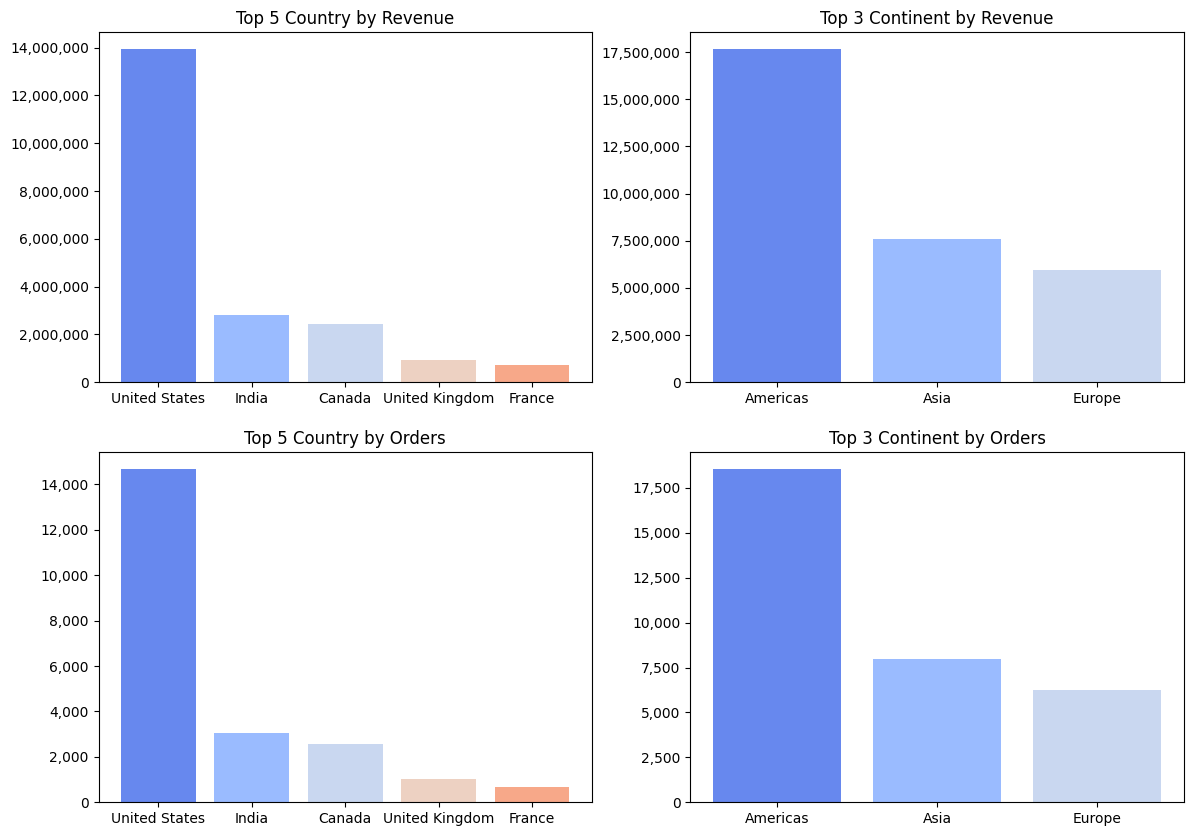

In [ ]:
# Топ 5 країн та Топ 3 континенти по продажах і замовленнях

# Фільтрація оригінального датасету по сесіях із замовленнями
orders_df = df[df["price"].notna()]

fig, ax = plt.subplots(2, 2, figsize=(14, 10))

# Форматування числових значень по осі Х
for i in range(2):
    for j in range(2):
        ax[i,j].tick_params(axis='x')
        ax[i,j].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# Групування доходу по 5 топових країнах
revenue_by_country = (orders_df.groupby("country")["price"].sum().sort_values(ascending=False).head(5))
colors = sns.color_palette("coolwarm")

ax[0,0].bar(revenue_by_country.index, revenue_by_country.values, color=colors)
ax[0,0].set_title("Top 5 Country by Revenue")

# Групування доходу по 3 топових континентах
revenue_by_continent = (orders_df.groupby("continent")["price"].sum().sort_values(ascending=False).head(3))

ax[0,1].bar(revenue_by_continent.index, revenue_by_continent.values, color=colors)
ax[0,1].set_title("Top 3 Continent by Revenue")

# Групування замовлень по 5 топових країнах
order_by_country = (orders_df.groupby("country")["ga_session_id"].nunique().sort_values(ascending=False).head(5))

ax[1,0].bar(order_by_country.index, order_by_country.values, color=colors)
ax[1,0].set_title("Top 5 Country by Orders")

# Групування замовлень по 3 топових континентах
order_by_continent = (orders_df.groupby("continent")["ga_session_id"].nunique().sort_values(ascending=False).head(3))

ax[1,1].bar(order_by_continent.index, order_by_continent.values, color=colors)
ax[1,1].set_title("Top 3 Continent by Orders")

Графіки демонструють однаковий набір топових країн та континентів як в розрізі доходу так і в розрізі кількості замовлень. До топ-5 країн відносяться США, Індія, Канада, Велика Британія, Франція. Топ-3 континенти: Америки, Азія, Європа. Оскільки топові ринки однаково лідирують як за доходом, так і за кількістю замовлень, це свідчить про їхню ключову роль у формуванні виручки.

Text(0.5, 1.0, 'Revenue by Category (USA)')

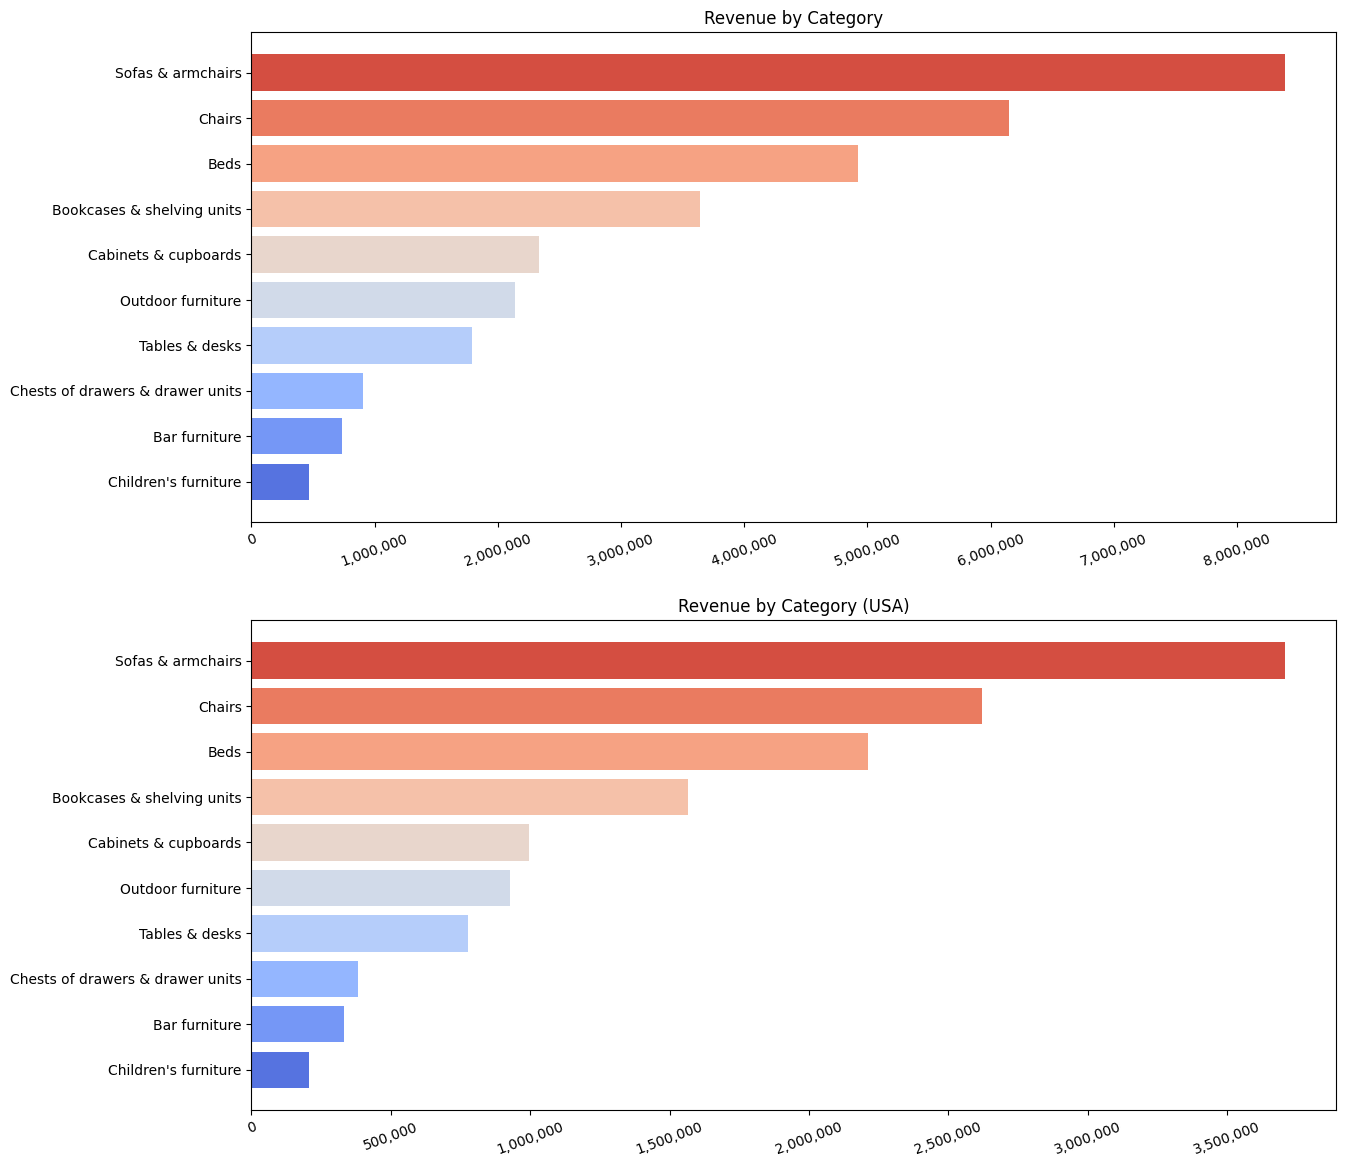

In [ ]:
# Tоп-10 категорій товарів за загальною сумою продажів по світу та окремо в США

fig, ax = plt.subplots(2, 1, figsize=(14, 14))

for i in range(2):
        ax[i].tick_params(axis='x', rotation = 20)
        ax[i].xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# Групування доходу по топ 10 категоріях
revenue_by_category = (orders_df.groupby("category")["price"].sum().sort_values(ascending=True).tail(10))
colors = sns.color_palette("coolwarm", 10)

ax[0].barh(revenue_by_category.index, revenue_by_category.values, color=colors)
ax[0].set_title("Revenue by Category")

# Створення окремого датафрейму із замовленнями для США
usa_df = orders_df[orders_df["country"] == "United States"]

# Групування доходу по категоріях для США
revenue_by_category_usa = (usa_df.groupby("category")["price"].sum().sort_values(ascending=True).tail(10))

ax[1].barh(revenue_by_category_usa.index, revenue_by_category_usa.values, color=colors)
ax[1].set_title("Revenue by Category (USA)")

Топ 10 категорій за продажами співпадають як для всього світу так і для топової країни (США). Співпадіння спостерігається також і в сортуванні категорій від найбільш до найменш прибуткової. Отже, ключові категорії мають універсальний попит і формують основу доходу незалежно від ринку.

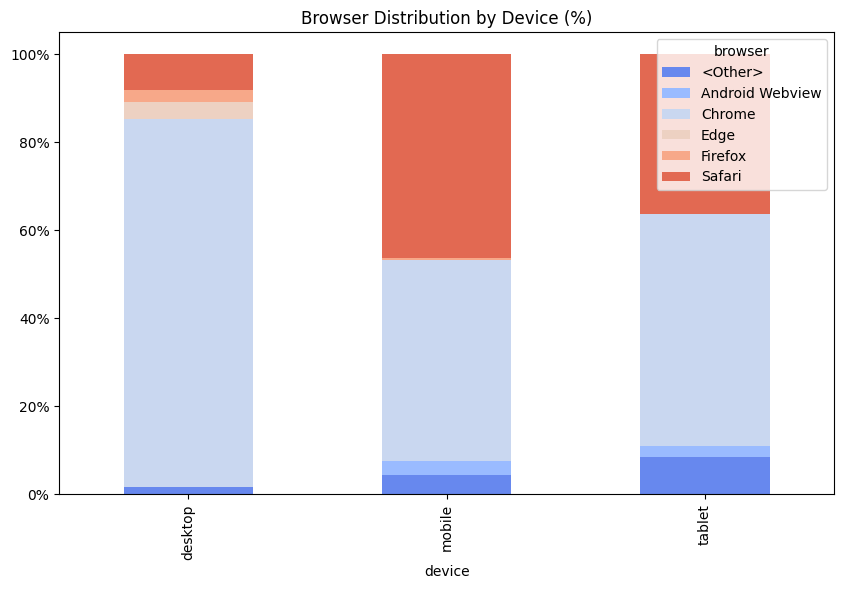

In [ ]:
#Аналіз продажів у розрізі типів та браузерів

# Збирємо необхідні дані у вигляді зведеної таблиці
pivot = (orders_df.pivot_table(index="device",columns="browser",values="price",aggfunc="sum"))

# Рахуємо продажі у відсотках від загального
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
colors = sns.color_palette("coolwarm")

# Візуалізація у вигляді нормованої діаграми
pivot_pct.plot(kind="bar", stacked=True, figsize=(10,6), color=colors)

plt.gca().yaxis.set_major_formatter(ticker.PercentFormatter())
plt.title("Browser Distribution by Device (%)")

plt.show()

Діаграма демонструє наступний розподіл доходу в залежності від типу браузеру: для desktop найбільший прибуток приносять користувачі браузера Chrome, для mobile - приблизно однаковий дохід компанія має від користувачів Chrome та Safari, для tablet топовим браузером є Chrome. Це може означати, що критично важливим є забепечення якісної роботи продукту в Chrome - як основному браузері.

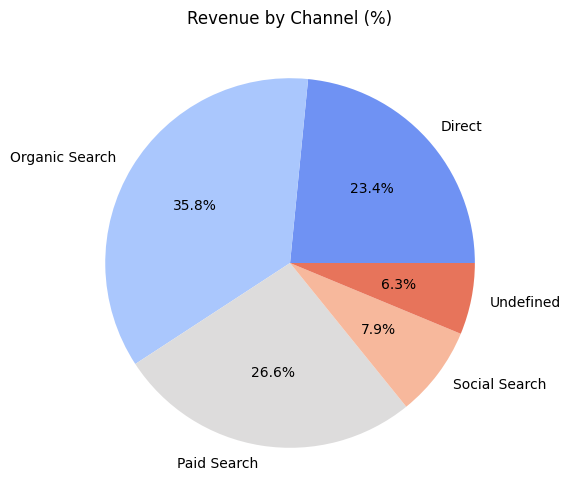

In [ ]:
# Аналіз продажів по каналам

# Групування доходу по каналах
temp = orders_df.groupby("channel")["price"].sum()

# Відсоток доходу від загального
channel_share = temp / temp.sum() * 100
colors = sns.color_palette("coolwarm", len(channel_share))

# Побудова діграми
plt.figure(figsize=(6,6))

plt.pie(channel_share.values, labels=channel_share.index, autopct='%1.1f%%', colors=colors)

plt.title("Revenue by Channel (%)")

plt.show()


Найбільш прибутковими є Organic Search, Paid Search та Direct. Це свідчить про те, що бізнес значно залежить від цих каналів як ключових джерел трафіку та доходу.

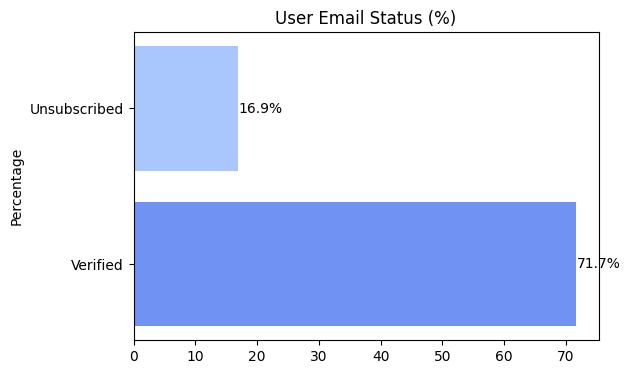

In [ ]:
# Розрахунок відсотка каристувачів із підтвердженою електронною адресою серед зареєстрованих.
# Розрахунок відсотка користувачів що відписались від розсилки серед зареєстрованих.

# Зареєстровані користувачі
registered_df = df[df["account_id"].notna()]

# Користувачі з підтвердженою електронною адресою
verified = (registered_df["is_verified"] == 1).sum()
total = len(registered_df)

# Відсоток верифікованих користувачів
percent_is_verified = verified / total * 100

# користувачі що відписались від розсилки
unsubscribed = (registered_df["is_unsubscribed"] == 1).sum()

# Відсоток відписаних користувачів
percent_is_unsubscribed = unsubscribed / total * 100

labels = ["Verified", "Unsubscribed"]
values = [percent_is_verified, percent_is_unsubscribed]

plt.figure(figsize=(6,4))

bars = plt.barh(labels, values, color=colors)

plt.title("User Email Status (%)")
plt.ylabel("Percentage")

plt.bar_label(bars, fmt='%.1f%%')

plt.show()


Серед усіх зареєстрованих користувачів 71.7% підтвердили свою адресу, в той час як 16.9% - відписались від розсилки. Це свідчить про достатньо високий рівень залученості користувачів після реєстрації, однак наявність частки відписок вказує на можливі проблеми з методом або частотою комунікацій.

## Аналіз динамічних показників

### Мета:дослідити динаміку доходу та виявити закономірності (циклічність, піки та спади), порівняти поведінку різних сегментів (канали, континенти, дні тижня) і на основі отриманих грфіків сформувати рекомендації для бізнеса щодо зростання доходу та оптимізації маркетингових активностей.

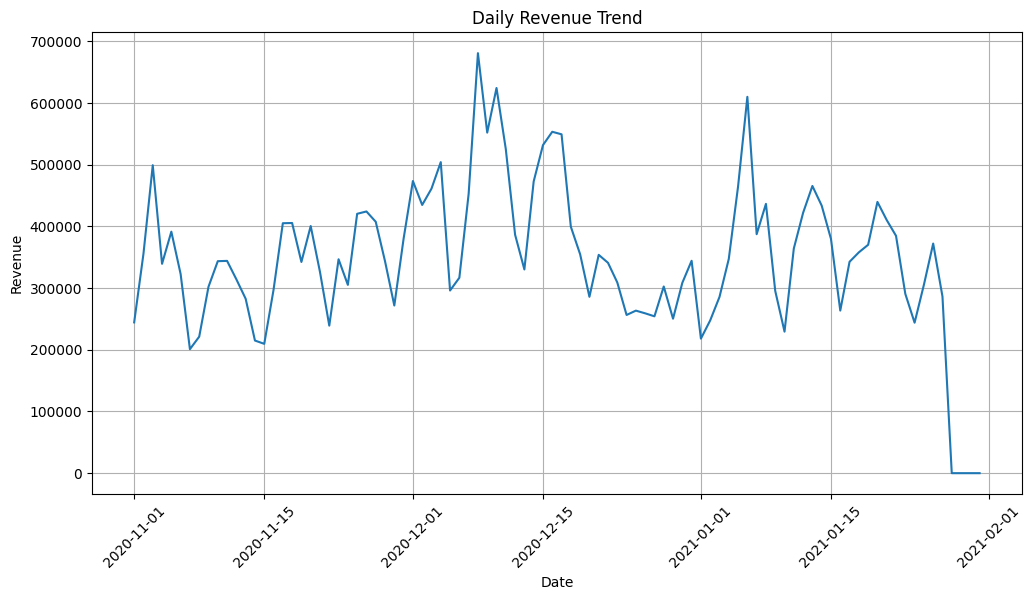

In [ ]:
# Загальна динаміка продажів

# Групування продажів по даті
daily_revenue = (df.groupby("session_date")["price"].sum().sort_index())

plt.figure(figsize=(12,6))

plt.plot(daily_revenue.index, daily_revenue.values)

plt.title("Daily Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.grid(True)
plt.xticks(rotation=45)

plt.show()

Динаміка загального доходу по днях характеризується певною волатильністю та циклічністю ймовірно повʼязаною з днями тижня. Це свідчить про регулярні коливання попиту, які варто враховувати при плануванні маркетингових активностей.

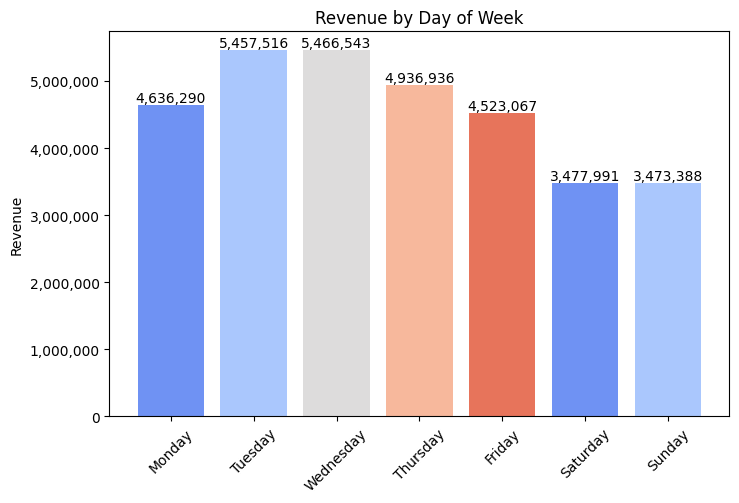

In [ ]:
# Загальні продажі по дням тижня

# Групування дат до дням тижня
df["weekday"] = df["session_date"].dt.day_name()

# Групування доходу по дням тижня
weekday_revenue = (df.groupby("weekday")["price"].sum())
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_revenue = weekday_revenue.reindex(weekday_order)

plt.figure(figsize=(8,5))

bars = plt.bar(weekday_revenue.index, weekday_revenue.values, color = colors)

plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.title("Revenue by Day of Week")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.bar_label(bars, fmt='{:,.0f}')

plt.show()

Маємо найбільші суми продажів для таких днів як Вівторк, Середа і поступове зниження до вихідних, в Суботу та Неділю сума продажів на найнижчому рівні. Це може свідчити про зміну поведінки користувачів на вихідних (менша онлайн-активність, інші пріоритети у вихідні дні). Ймовірно варто протестувати маркетингові активності в Суботу та Неділю (знижки, пуші, email-розсилки) для вирівнювання доходу протягом тижня.

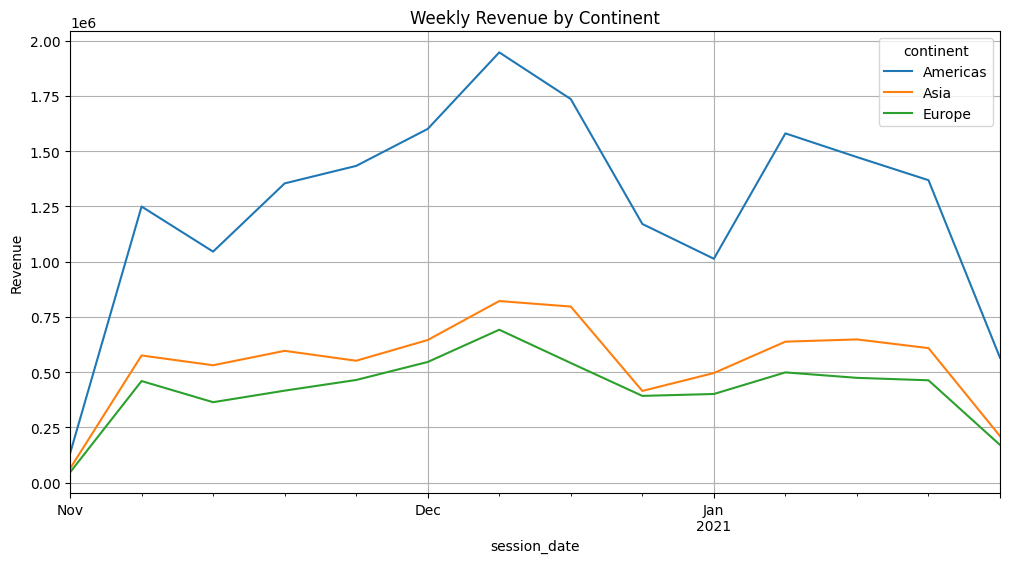

In [ ]:
# Динаміка продажів в Америці, Азії та Європі

continents = ["Europe", "Asia", "Americas"]
df_filtered = df[df["continent"].isin(continents)].copy()

#df_filtered["session_date"] = pd.to_datetime(df_filtered["session_date"])
df_filtered = df_filtered.set_index("session_date")

weekly_revenue = (df_filtered.groupby("continent")["price"].resample("W").sum().unstack(0))

weekly_revenue.plot(figsize=(12,6))
plt.grid(True)
plt.title("Weekly Revenue by Continent")
plt.ylabel("Revenue")

plt.show()


Америка демонструє найвищий рівень доходу протягом усього періоду спостереження. При цьому всі три континенти мають схожу динаміку продажів — піки та спади збігаються в часі, а також повторюють загальний тренд із максимальними значеннями на початку грудня та січня. Це може свідчити про вплив спільних зовнішніх факторів, таких як сезонність, маркетингові активності, святкові періоди, а також періоди виплат заробітної плати, які можуть стимулювати зростання споживчої активності.

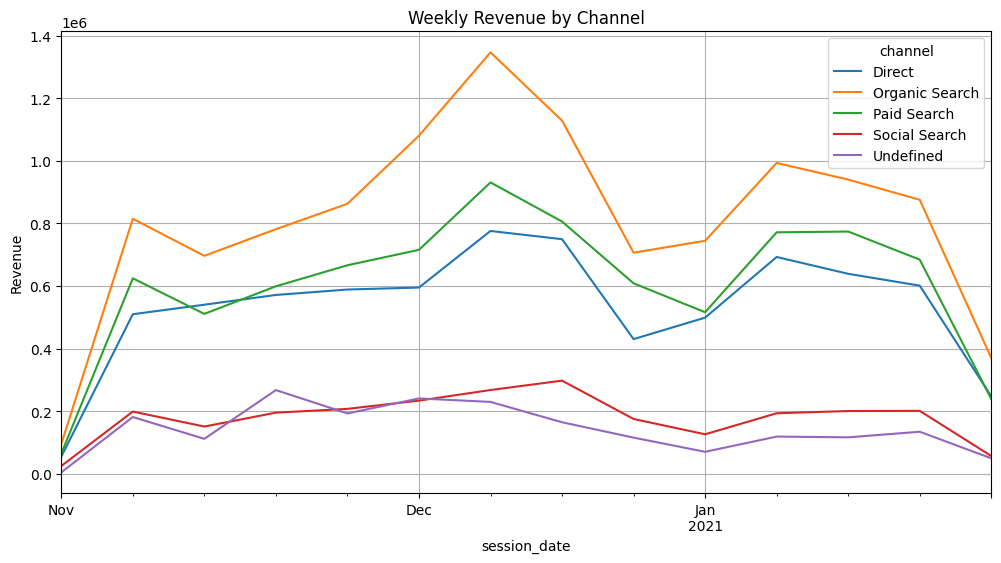

In [ ]:
# Динаміка продажів у розрізі каналів трафіку

# Датасет з датами-індексами
df_temp = df.set_index("session_date")

# групування по каналах
weekly_revenue_channel = (df_temp.groupby("channel")["price"].resample("W").sum().unstack(0))

weekly_revenue_channel.plot(figsize=(12,6))

plt.grid(True)
plt.title("Weekly Revenue by Channel")
plt.ylabel("Revenue")

plt.show()

Найбільший дохід бізнесу приносить канал Organic Search, також високі показники спостерігаються в каналах Direct та Paid Search. Загалом ці три канали дублюють загальний тренд піків та спадів, що обумовлено впливом зовнішніх факторів. Водночас канали Social Search та невизначені джерела демонструють стабільно низький рівень доходу, що вказує на потенціал для тестування та масштабування активностей у наприклад для Social Search.

##Багатовимірний аналіз доходу

### Мета: аналіз структури доходу за категоріями та країнами, оцінка середнього доходу на користувача по ключових країнах для виявлення найбільш прибуткових сегментів та визначення можливостей для зростання і масштабування бізнесу.

In [ ]:
#Загальні продажі за категоріями товарів (топ-10 категорій) у різних країнах (топ-5 країн)

# Фільтрація по країні
top_countries = (orders_df.groupby("country")["price"].sum().sort_values(ascending=False).head(5).index)
# Фільтрація по категорії
top_categories = (orders_df.groupby("category")["price"].sum().sort_values(ascending=False).head(10).index)

# Застосування спільного фільтра
filtered_df = orders_df[(orders_df["country"].isin(top_countries)) & (orders_df["category"].isin(top_categories))]

pivot = filtered_df.pivot_table(
    index="category",
    columns="country",
    values="price",
    aggfunc="sum")

pivot = pivot.fillna(0)
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]
pivot = pivot.loc[:, pivot.sum(axis=0).sort_values(ascending=False).index]
pivot.style.format("{:,.0f}").background_gradient(cmap="Blues").set_caption("Top Categories by Revenue across Top Countries")


country,United States,India,Canada,United Kingdom,France
category,,,,,
Sofas & armchairs,"3,707,144","788,430","692,428","234,812","187,735"
Chairs,"2,619,774","544,309","417,741","188,519","134,029"
Beds,"2,213,058","358,320","354,772","133,816","116,414"
Bookcases & shelving units,"1,567,607","364,507","278,982","113,988","73,830"
Cabinets & cupboards,"994,546","191,888","181,802","71,684","59,102"
Outdoor furniture,"929,245","162,289","185,323","57,002","40,486"
Tables & desks,"777,865","186,158","132,678","49,374","42,299"
Chests of drawers & drawer units,"382,388","73,111","71,952","36,784","21,544"
Bar furniture,"330,805","57,657","51,724","22,103","11,199"


Розподіл категорій у топових країнах є схожим і відповідає загальному тренду, що свідчить про універсальний попит на ключові категорії. Це свідчить про те що маркетингові стратегії можуть буди уніфікованими для всіх ринків.

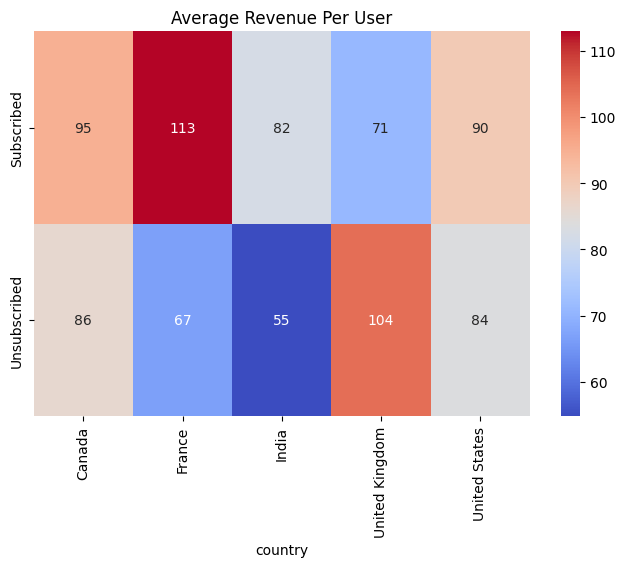

In [ ]:
#Середній дохід на користувача по топ-країнах

# Топові країни
top_countries = (orders_df.groupby("country")["price"].sum().sort_values(ascending=False).head(5).index)

# Зареєстровані користувачі
registered_df = df[df["account_id"].notna()]

# Датафрейм відфільтрований по топ країнам та наявності реєстрації
subscription_df = registered_df[(registered_df["country"].isin(top_countries)) & (registered_df["is_unsubscribed"].notna())]

# Зведена таблиця з сумарним доходом на зареєстрованих користувачів по топовим країнам
pivot = subscription_df.pivot_table(
    index="is_unsubscribed",
    columns="country",
    values="price",
    aggfunc="sum")

# Зведена таблиця з кількістю зареєстрованих користувачів по топовим країнам
pivot_users = subscription_df.pivot_table(
    index="is_unsubscribed",
    columns="country",
    values="account_id",
    aggfunc="nunique")

#Середній дохід на зареєстрованого користувача (підписаного/відписаного)
arpu = pivot / pivot_users
arpu.index = ["Subscribed", "Unsubscribed"] # 0=Subscribed, 1=Unsubscribed

plt.figure(figsize=(8,5))

sns.heatmap(arpu, annot=True, fmt=".0f", cmap="coolwarm")
plt.title("Average Revenue Per User")
plt.show()




У більшості країн (Канада, Франція, Індія) підписані користувачі мають вищий ARPU, що свідчить про ефективність комунікацій із цією аудиторією. У США різниця між сегментами є незначною, що може свідчити про нейтральний вплив підписки на дохід. В той час як у Великій Британії підписка не корелює з вищим ARPU. Це може свідчити про неефективність поточних комунікацій або специфіку поведінки користувачів. Рекомендується додатково проаналізувати контент, частоту розсилок, а також протестувати можливі альтернативні підходи до взаємодії з аудиторією.

## Статистичний аналіз взаємозвʼязків

###Мета: проаналізувати вплив обсягу трафіку та каналів залучення на загальний дохід компанії, виявити статистично значущі взаємозв’язки між показниками та визначити ключові фактори, що впливають на зростання продажів.

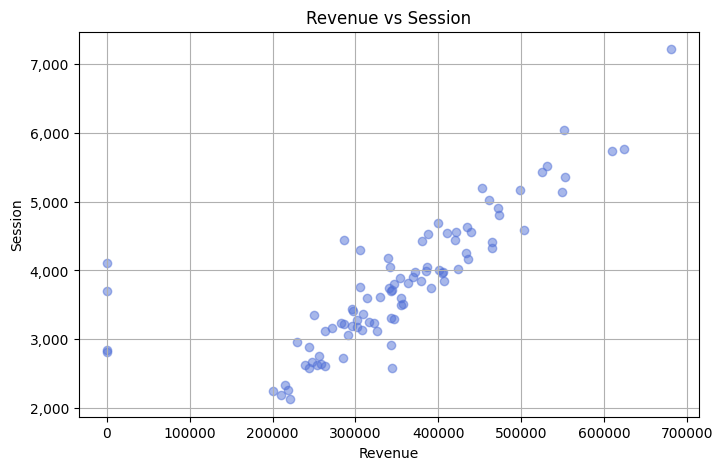

Тестова статистика і p-value: {PearsonRResult(statistic=np.float64(0.7910809164540891), pvalue=np.float64(6.483532312080735e-21))}
Коефіцієнт кореляції Пірсона: {np.float64(0.7910809164540888)}


In [ ]:
#Виявлення взаємозвʼязку між кількістю сесій та загальними продажами за кожну дату.

# Групування доходу по даті
daily_revenue = (df.groupby("session_date")["price"].sum().sort_index())
# Групування сесій по даті
daily_session = (df.groupby("session_date")["ga_session_id"].nunique().sort_index())

# Датафрейм Дохід+Сесії
daily_df = pd.DataFrame({"revenue": daily_revenue,"sessions": daily_session})

plt.figure(figsize=(8, 5))

plt.scatter(daily_df["revenue"], daily_df["sessions"], alpha=0.5, color="#5170d7")
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.xlabel("Revenue")
plt.ylabel("Session")
plt.title("Revenue vs Session")
plt.grid(True)
plt.show()

from scipy.stats import pearsonr

# Розрахунок коефіцієнта кореляції та статитстичної значущості
print("Тестова статистика і p-value:", {pearsonr(daily_df["revenue"], daily_df["sessions"])})

pearson_corr = daily_df["revenue"].corr(daily_df["sessions"])
print("Коефіцієнт кореляції Пірсона:", {pearson_corr})


Оскільки p-value < 0.05, взаємозв'язок між кількістю сесій та загальними продажами є статистично значущим. За величиною коефіцієнта кореляції, приблизно 0.791, робимо висновок, що змінні мають сильний прямий зв'язок. Це означає, що збільшення кількості сесій може бути ефективним інструментом в підвищенні продажів.


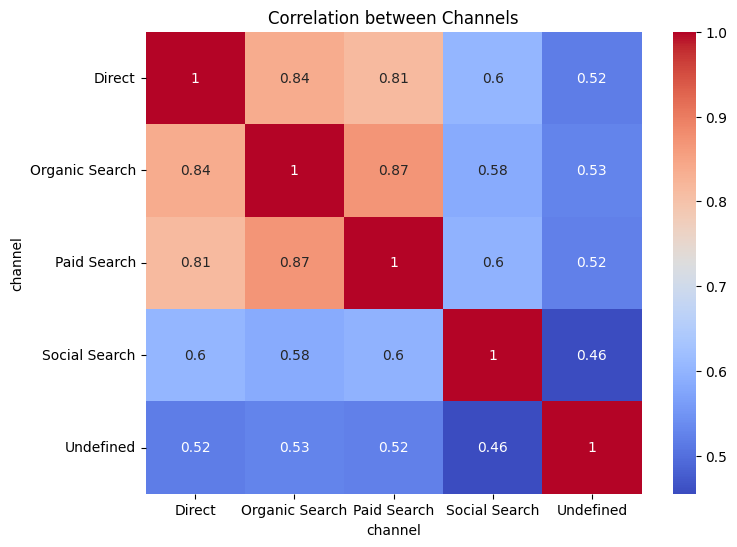

,channel_1,channel_2,correlation,p_value
0,Direct,Organic Search,0.837833,2.190420e-25
1,Direct,Paid Search,0.814072,5.896435e-23
2,Direct,Social Search,0.604060,1.831889e-10
3,Direct,Undefined,0.517505,1.275436e-07
4,Organic Search,Paid Search,0.870086,2.142003e-29
5,Organic Search,Social Search,0.583117,1.066192e-09
6,Organic Search,Undefined,0.526068,7.228214e-08
7,Paid Search,Social Search,0.596428,3.532284e-10
8,Paid Search,Undefined,0.521961,9.509609e-08
9,Social Search,Undefined,0.455126,5.161928e-06


In [ ]:
# Кореляція продажів за різними каналами трафіку. Визначення статистичної значущості

# Агрегація доходу по даті та каналу
channel_daily = (df.groupby(["session_date", "channel"])["price"].sum().reset_index())

#Зведена таблиця по даті, каналу, продажам
pivot = channel_daily.pivot_table(index="session_date",columns="channel",values="price").fillna(0)
# Визначення коефіцієнта кореляції
corr_matrix = pivot.corr()

plt.figure(figsize=(8,6))

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation between Channels")
plt.show()


# Виділення каналів
channels = pivot.columns

results = []


# Розрахунок кореляції та p-value для кожної пари каналів
for i in range(len(channels)):
    for j in range(i+1, len(channels)):
        ch1 = channels[i]
        ch2 = channels[j]

        corr, p_value = pearsonr(pivot[ch1], pivot[ch2])

        results.append({
            "channel_1": ch1,
            "channel_2": ch2,
            "correlation": corr,
            "p_value": p_value})

results_df = pd.DataFrame(results)
results_df


Між каналами Direct, Organic Search та Paid Search спостерігається сильна позитивна кореляція (виже 0.8), що свідчить про те, що їхні продажі змінюються синхронно у часі, що підтверджує також і аналіз динамічного графіку. Взаємозвʼязки між каналами є статистично значущими (p-value < 0.05).
Отже можливі зміни у маркетинговій стратегії або зовнішньому середовищі, ймовірно, одночасно впливатимуть на всі ключові канали.

##Статистичний аналіз відмінностей між групами.

###Мета: проаналізувати відмінності в продажах та поведінці користувачів за ключовими сегментами (статус реєстрації, канал залучення, девайс), перевірити статистичну значущість цих відмінностей та визначити фактори, що впливають на дохід і конверсію для подальшої оптимізації маркетингової стратегії.

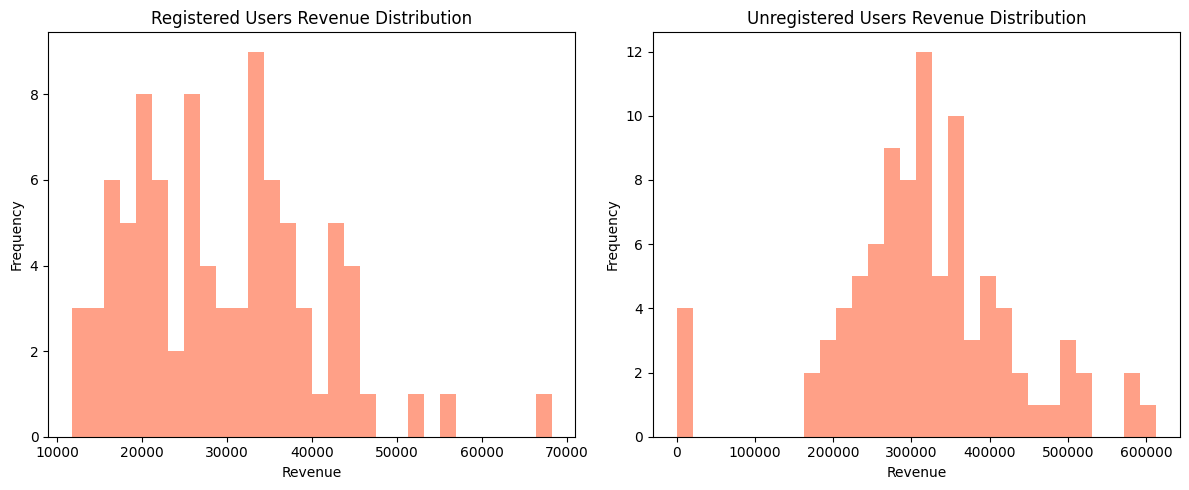

In [ ]:
# Аналіз продажів серед зареєстрованих та незареєстрованих користувачів

with_registrations = (df[df["account_id"].notna()].groupby("session_date")["price"].sum())
without_registrations = (df[df["account_id"].isna()].groupby("session_date")["price"].sum())

plt.figure(figsize=(12,5))

# Зареєстровані (розподіл)
plt.subplot(1, 2, 1)
plt.hist(with_registrations, bins=30, alpha=0.7, color="#ff7855")
plt.title("Registered Users Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")

# Незареєстровані (розподіл)
plt.subplot(1, 2, 2)
plt.hist(without_registrations, bins=30, alpha=0.7, color="#ff7855")
plt.title("Unregistered Users Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


Обидві гістограми візуально не відповідають нормальному розподілу значень у вибірках. Але для остаточних висновків звернемось до додаткових тестів.

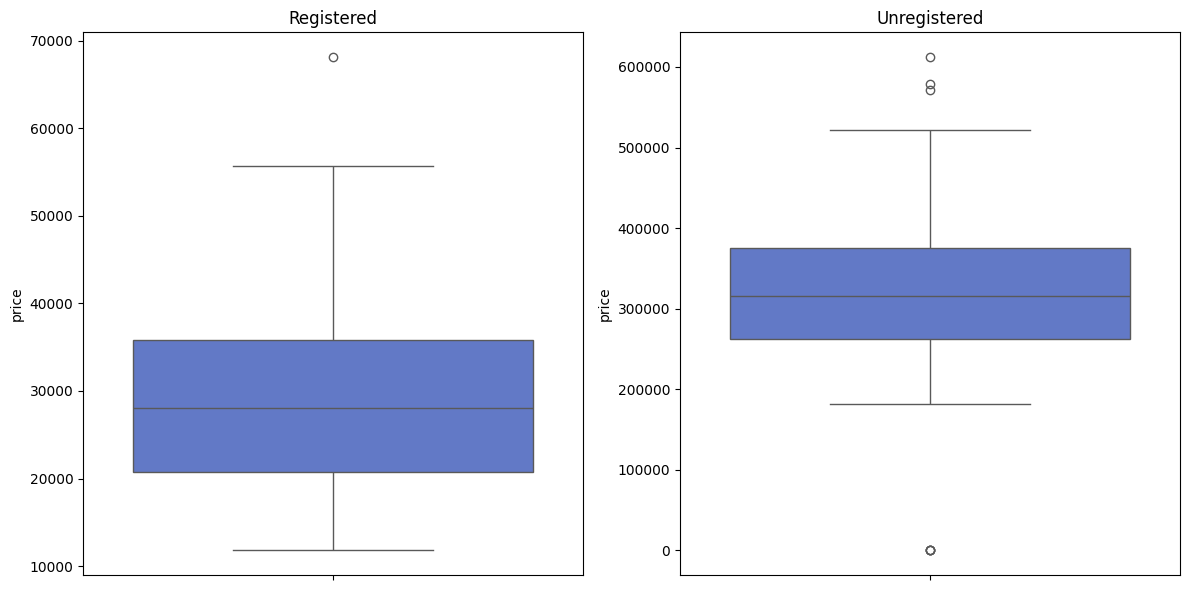

Тест Шапіро на визначення нормальності розподілу для зареєстрованих користувачів: ShapiroResult(statistic=np.float64(0.9591810175035426), pvalue=np.float64(0.007295139880540744))
Тест Шапіро на визначення нормальності розподілу для незареєстрованих користувачів: ShapiroResult(statistic=np.float64(0.9487769113384333), pvalue=np.float64(0.0012184604855253293))


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

sns.boxplot(y=with_registrations, ax=ax[0], color="#5170d7")
ax[0].set_title("Registered")

sns.boxplot(y=without_registrations, ax=ax[1], color="#5170d7")
ax[1].set_title("Unregistered")

plt.tight_layout()
plt.show()

# Тест Шапіро на визначення нормальності розподілу
from scipy.stats import shapiro

print("Тест Шапіро на визначення нормальності розподілу для зареєстрованих користувачів:", shapiro(with_registrations))
print("Тест Шапіро на визначення нормальності розподілу для незареєстрованих користувачів:",shapiro(without_registrations))

Аналіз розподілу щоденного доходу від зареєстрованих та незареєстрованих користувачів показав суттєві відмінності.
Незареєстровані користувачі демонструють значно вищу медіану доходу (більше 300000) та більший розкид значень, а також наявність екстремально високих значень.
Це свідчить про те, що значна частина покупок здійснюється без реєстрації.
Водночас розподіл доходу є нерівномірним і містить значні викиди.

Для перевірки розподілу на нормальність оберемо тест Шапіро. В результаті бачимо значення p-value для обох вибірок < 0.05, а отже розподіл не є нормальним. Для подальшого аналізу оберемо тест Манна-Уітні, що дозволяє робити висновки для ненормально розподілених вибірок.

In [ ]:
# Перевірка статистичної значущості різниці у доході між сегментами за допомогою тесту Манна–Уітні
from scipy.stats import mannwhitneyu

stat, p_value = mannwhitneyu(
    with_registrations,
    without_registrations)
print("P-value:", p_value)

P-value: 3.8805185465235906e-26


За результатами теста Манна-Уітні (p-value < 0.05) спостерігається статистично значуща різниця між розподілами щоденного доходу від зареєстрованих та незареєстрованих користувачів. Це може свідчити про те що поточні механізми комунікації та утримання із зареєстрованими користувачами є недостатньо ефективними.

In [ ]:
# Конверсія в покупку за наявністю реєстрації

df["converted"] = df["price"].notna()
df["is_registered"] = df["account_id"].notna()

# Розрахунок конверсії
conversion_reg = df.groupby("is_registered").agg(sessions=("ga_session_id", "nunique"),conversions=("converted", "sum"))

conversion_reg["conversion_rate"] = (conversion_reg["conversions"] / conversion_reg["sessions"])

# Тест пропорцій
from statsmodels.stats.proportion import proportions_ztest

success = conversion_reg["conversions"]
total = conversion_reg["sessions"]

stat, p_value = proportions_ztest(success, total)
print("P-value:", p_value)

cr = conversion_reg["conversion_rate"]

print("Зареєстровані:", cr[True])
print("Незареєстровані:", cr[False])

uplift = (cr[True] - cr[False]) / cr[False] * 100
print("Різниця в конверсіях:", uplift)


P-value: 0.03467676423596537
Зареєстровані: 0.09951690821256039
Незареєстровані: 0.09563743781094527
Різниця в конверсіях: 4.056434896639529


Було порівняно conversion rate між зареєстрованими та незареєстрованими користувачами. За результатами тесту пропорцій (p-value = 0.035 < 0.05), різниця між групами є статистично значущою, що свідчить про наявність зв’язку між реєстрацією користувача та ймовірністю здійснення покупки. Зареєстровані користувачі мають дещо вищий conversion rate порівняно з незареєстрованими (9.95% vs 9.56%).
Різниця становить близько 0.39 (збільшення на 4%).

Це свідчить про наявність зв’язку між реєстрацією та ймовірністю покупки, однак величина ефекту є помірною.

Таким чином, реєстрація пов’язана з підвищенням конверсії, але не обов’язково зростанням доходу. Це вказує на необхідність окремого підходу до цих сегментів: для незареєстрованих — зберегти високий середній чек і впливати на підвищення реєстрації, а для зареєстрованих — працювати над збільшенням середнього чеку та доходу.


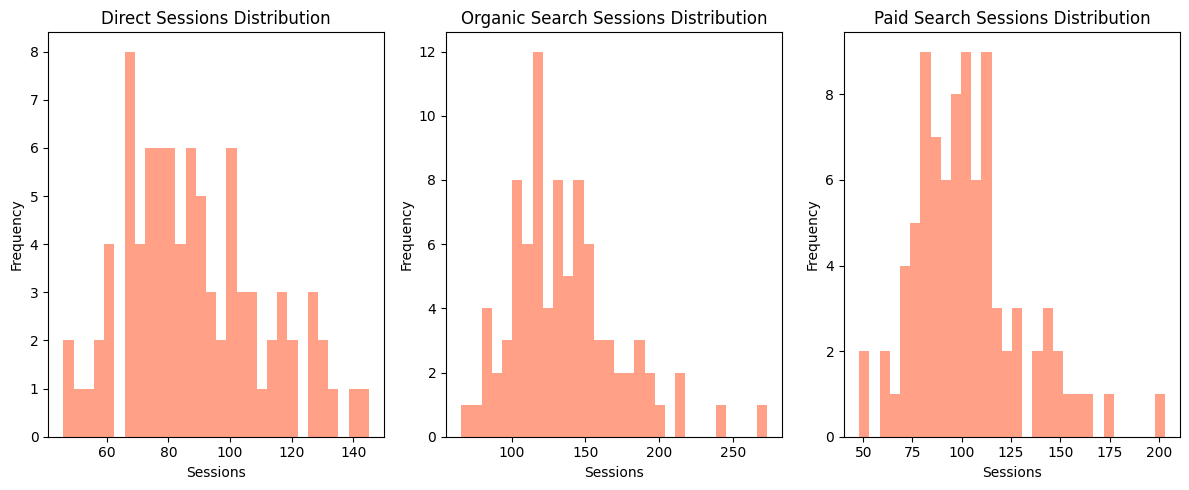

In [ ]:
# Аналіз кількості сесій за різними каналами трафіку.

# Агрегація по каналу
df_direct = orders_df[orders_df["channel"] == "Direct"]
session_direct = (df_direct.groupby("session_date")["ga_session_id"].nunique())

df_organic = orders_df[orders_df["channel"] == "Organic Search"]
session_organic = (df_organic.groupby("session_date")["ga_session_id"].nunique())

df_paid= orders_df[orders_df["channel"] == "Paid Search"]
session_paid = (df_paid.groupby("session_date")["ga_session_id"].nunique())

plt.figure(figsize=(12,5))


plt.subplot(1, 3, 1)
plt.hist(session_direct, bins=30, alpha=0.7, color="#ff7855")
plt.title("Direct Sessions Distribution")
plt.xlabel("Sessions")
plt.ylabel("Frequency")


plt.subplot(1, 3, 2)
plt.hist(session_organic, bins=30, alpha=0.7, color="#ff7855")
plt.title("Organic Search Sessions Distribution")
plt.xlabel("Sessions")
plt.ylabel("Frequency")

plt.subplot(1, 3, 3)
plt.hist(session_paid, bins=30, alpha=0.7, color="#ff7855")
plt.title("Paid Search Sessions Distribution")
plt.xlabel("Sessions")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()




In [ ]:
print("Тест Шапіро на визначення нормальності розподілу для каналу Direct:", shapiro(session_direct))
print("Тест Шапіро на визначення нормальності розподілу для каналу Organic Search:",shapiro(session_organic))
print("Тест Шапіро на визначення нормальності розподілу для каналу Paid Search:",shapiro(session_paid))

Тест Шапіро на визначення нормальності розподілу для каналу Direct: ShapiroResult(statistic=np.float64(0.9754365241418611), pvalue=np.float64(0.09281356505418345))
Тест Шапіро на визначення нормальності розподілу для каналу Organic Search: ShapiroResult(statistic=np.float64(0.949834630772818), pvalue=np.float64(0.0018864052548891136))
Тест Шапіро на визначення нормальності розподілу для каналу Paid Search: ShapiroResult(statistic=np.float64(0.9539759958496163), pvalue=np.float64(0.00339715035615623))


Тест Шапіро демонструє p-value < 0.05 для каналів Organic Search та Paid Search, отже розподіл не є нормальним, для каналу Direct маємо нормальний розподіл. Але так як 2 вибірки розподілені ненормально, для подальшого аналізу необхідно використати тест Крускала Уолліса.

In [ ]:
from scipy.stats import kruskal

stat, p_value = kruskal(session_direct, session_organic, session_paid)

print("P-value:", p_value)

P-value: 2.9176190420834663e-19



Результати тесту показали статистично значущу різницю між каналами (p-value < 0.05), що свідчить про те, що розподіли щоденного трафіку відрізняються між каналами Direct, Organic Search та Paid Search.
Отже канали генерують кількість сесій по-різному і їх не можна вважати однаковими з точки зору трафіку. Це вказує на те що кожен канал має свою власну специфіку залечення користувачів до трафіка, а отже вимагає і окремого підходу до оптимізації цих процесів.

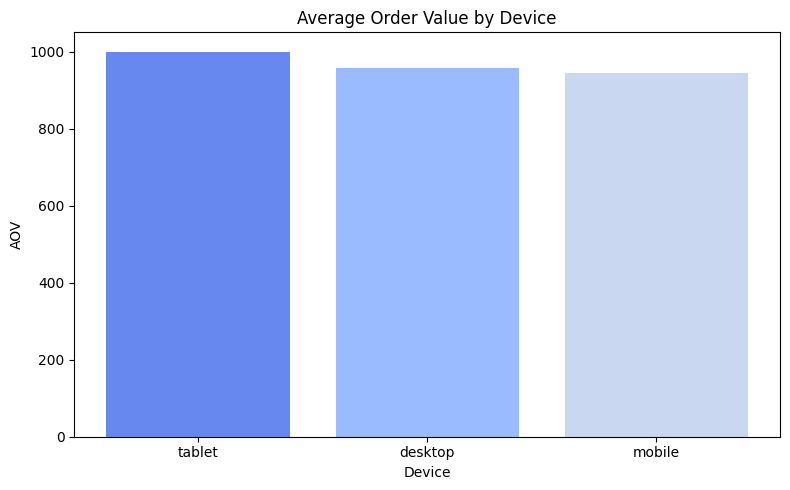

In [ ]:

# Аналіз середнього чеку в розрізі девайсів

# Агрегація по середньому чеку для кожного девайсу
aov_device = orders_df.groupby("device")["price"].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))

plt.bar(aov_device.index, aov_device.values, color=sns.color_palette("coolwarm"))
plt.title("Average Order Value by Device")
plt.xlabel("Device")
plt.ylabel("AOV")

plt.tight_layout()
plt.show()

In [ ]:
desktop = orders_df[orders_df["device"] == "desktop"]["price"]
mobile = orders_df[orders_df["device"] == "mobile"]["price"]
tablet = orders_df[orders_df["device"] == "tablet"]["price"]

# Перевірка нормальності (тест Шапіро працює для вибірок приблизно до 5000 елементів)
stat, p_for_desktop = shapiro(desktop.sample(min(len(desktop), 5000), random_state=42))
stat, p_for_mobile = shapiro(mobile.sample(min(len(mobile), 5000), random_state=42))
stat, p_for_tablet = shapiro(tablet.sample(min(len(tablet), 5000), random_state=42))
print("Тест Шапіро на визначення нормальності розподілу для desktop:", p_for_desktop)
print("Тест Шапіро на визначення нормальності розподілу для mobile:",p_for_mobile)
print("Тест Шапіро на визначення нормальності розподілу для tablet:",p_for_tablet)

Тест Шапіро на визначення нормальності розподілу для desktop: 6.0507786891781516e-71
Тест Шапіро на визначення нормальності розподілу для mobile: 1.5435632411588798e-70
Тест Шапіро на визначення нормальності розподілу для tablet: 1.7262462406178557e-34


In [ ]:
# Тест Крускала-Уоліса
from scipy.stats import kruskal

stat, p_value = kruskal(desktop, mobile, tablet)
print("Крускал-Уолліс AOV по девайсах:", p_value)

Крускал-Уолліс AOV по девайсах: 0.12284897882315772


Середній чек статистично значущо не відрізняється між desktop, mobile та tablet користувачами (p-value = 0.123). Це свідчить про те, що тип пристрою не впливає на суму замовлення — користувачі однаково витрачають незалежно від того, з якого девайсу здійснюють покупку. Таким чином, оптимізація UX або маркетингових активностей за пристроями  ймовірно не дасть значного впливу на середній чек.


[Дашборд Tableau](https://public.tableau.com/shared/ZC6KTTHBH?:display_count=n&:origin=viz_share_link)